# Set up SQLite with Titanic:

In [1]:
import sqlite3
import pandas as pd
import numpy as np

# load Titanic
df = pd.read_csv('train.csv')

# create SQLite database in memory
conn = sqlite3.connect(':memory:')

# load DataFrame into SQLite table
df.to_sql('titanic', conn, index=False, if_exists='replace')

print("Database created successfully")
print(f"Rows loaded: {pd.read_sql('SELECT COUNT(*) as total FROM titanic', conn).iloc[0,0]}")

Database created successfully
Rows loaded: 891


In [4]:
q = pd.read_sql("""
SELECT * FROM (
    SELECT PassengerId, Name, Pclass, Fare,
       ROW_NUMBER() OVER (PARTITION BY Pclass ORDER BY Fare DESC) as rank
    FROM titanic )
WHERE rank <= 3
""", conn)
print(q)

   PassengerId                                Name  Pclass      Fare  rank
0          259                    Ward, Miss. Anna       1  512.3292     1
1          680  Cardeza, Mr. Thomas Drake Martinez       1  512.3292     2
2          738              Lesurer, Mr. Gustave J       1  512.3292     3
3           73                Hood, Mr. Ambrose Jr       2   73.5000     1
4          121         Hickman, Mr. Stanley George       2   73.5000     2
5          386           Davies, Mr. Charles Henry       2   73.5000     3
6          160          Sage, Master. Thomas Henry       3   69.5500     1
7          181        Sage, Miss. Constance Gladys       3   69.5500     2
8          202                 Sage, Mr. Frederick       3   69.5500     3


In [12]:
q = pd.read_sql("""
    SELECT PassengerId, Name, Pclass, Fare,
       COUNT(*) OVER (ORDER BY PassengerId ) as cumulative_passengers,
       SUM(Fare) OVER (ORDER BY PassengerId) as cummulative_fare
    FROM titanic 
""", conn)
print(q)

     PassengerId                                               Name  Pclass  \
0              1                            Braund, Mr. Owen Harris       3   
1              2  Cumings, Mrs. John Bradley (Florence Briggs Th...       1   
2              3                             Heikkinen, Miss. Laina       3   
3              4       Futrelle, Mrs. Jacques Heath (Lily May Peel)       1   
4              5                           Allen, Mr. William Henry       3   
..           ...                                                ...     ...   
886          887                              Montvila, Rev. Juozas       2   
887          888                       Graham, Miss. Margaret Edith       1   
888          889           Johnston, Miss. Catherine Helen "Carrie"       3   
889          890                              Behr, Mr. Karl Howell       1   
890          891                                Dooley, Mr. Patrick       3   

        Fare  cumulative_passengers  cummulative_fa

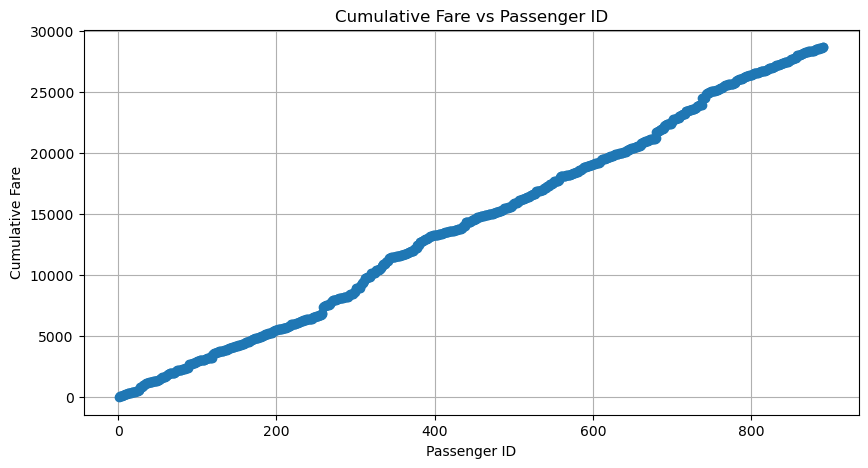

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

q = pd.read_sql("""
    SELECT PassengerId,
           Fare,
           SUM(Fare) OVER (ORDER BY PassengerId) AS cumulative_fare
    FROM titanic
""", conn)

plt.figure(figsize=(10,5))
plt.plot(q["PassengerId"], q["cumulative_fare"], marker="o")

plt.xlabel("Passenger ID")
plt.ylabel("Cumulative Fare")
plt.title("Cumulative Fare vs Passenger ID")
plt.grid(True)

plt.show()

In [18]:
print(q.head())

   PassengerId     Fare  cumulative_fare
0            1   7.2500           7.2500
1            2  71.2833          78.5333
2            3   7.9250          86.4583
3            4  53.1000         139.5583
4            5   8.0500         147.6083
